# Corpus SIREVA-SUS: Pipeline UD
Pipeline para construção de corpus Universal Dependencies a partir de relatórios epidemiológicos SIREVA-SUS

## 1. Instalações

In [1]:
!pip install torch docling --extra-index-url https://download.pytorch.org/whl/cpu
!pip install docling stanza ufal.udpipe
!pip -q install transformers ufal.chu-liu-edmonds huggingface_hub
!pip3 install ufal.chu_liu_edmonds pypdf pymupdf
!python -m spacy download pt_core_news_lg
!git clone https://huggingface.co/spaces/NILC-ICMC-USP/Portparser.v2
!pip install udapi conllu -q

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cpu
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 9.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.4/397.4 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.1/241.1 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 120.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.7/42.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 124.5 MB/s eta 0:00:00
  

## 2. Imports e Configuração

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import csv
import os
import re
import glob
import subprocess
import urllib.request
from pathlib import Path
from typing import List, Dict, Any, Optional
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from huggingface_hub import snapshot_download
from docling.document_converter import DocumentConverter

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

In [4]:
TERMOS_CHAVE = ["meningite", "pneumonia", "bacteriana", "vigilância"]

url = "https://raw.githubusercontent.com/jwijffels/udpipe.models.ud.2.5/master/inst/udpipe-ud-2.5-191206/portuguese-gsd-ud-2.5-191206.udpipe"
udpipe_model_path = "portuguese-gsd-ud-2.5-191206.udpipe"
urllib.request.urlretrieve(url, udpipe_model_path)
print("Modelo UDPipe baixado em:", udpipe_model_path)

Modelo UDPipe baixado em: portuguese-gsd-ud-2.5-191206.udpipe


In [5]:
INPUT_PDF = "/content/drive/MyDrive/IC/SIREVA/sireva_2024.pdf"
OUT_DIR = Path("saida_corpus")
OUT_DIR.mkdir(parents=True, exist_ok=True)

CONLLU_DIR = OUT_DIR / "conllu"
CONLLU_DIR.mkdir(parents=True, exist_ok=True)

UDPIPE_MODEL_PATH = "/content/portuguese-gsd-ud-2.5-191206.udpipe"
BASE_PP = Path("/content/Portparser.v2").resolve()

os.environ["KERAS_BACKEND"] = "torch"

## 3. Funções de Extração de Texto

In [6]:
def extrair_texto_raw_pdf(pdf_path: str) -> str:
    from pypdf import PdfReader
    reader = PdfReader(pdf_path)
    return "\n".join([(p.extract_text() or "") for p in reader.pages])


def extrair_texto_pymupdf(pdf_path: str) -> str:
    import fitz
    doc = fitz.open(pdf_path)
    parts = []
    for page in doc:
        parts.append(page.get_text("text"))
    doc.close()
    return "\n".join(parts)


def carregar_docling(pdf_path: str):
    converter = DocumentConverter()
    result = converter.convert(pdf_path)
    return result.document


def exportar_texto_docling_text_only(doc, out_dir: Path) -> Path:
    texto = doc.export_to_text()
    p = out_dir / "docling_text_only.txt"
    p.write_text(texto, encoding="utf-8")
    print("[OK] Docling text-only salvo em", p)
    return p


def exportar_tabelas_para_csv(doc, out_dir: Path, salvar_parquet: bool = True) -> List[Path]:
    tabelas_dir = out_dir / "tabelas_csv"
    tabelas_dir.mkdir(parents=True, exist_ok=True)
    tabelas_out: List[Path] = []

    if not hasattr(doc, "tables") or not doc.tables:
        print("[AVISO] Docling não retornou doc.tables.")
        return tabelas_out

    for idx, table in enumerate(doc.tables, start=1):
        try:
            df = table.export_to_dataframe(doc=doc)
        except Exception as e:
            print(f"[AVISO] Falha ao exportar tabela {idx}: {e}")
            continue

        csv_path = tabelas_dir / f"tabela_{idx:02d}.csv"
        df.to_csv(csv_path, index=False, encoding="utf-8")
        tabelas_out.append(csv_path)

        if salvar_parquet:
            pq_path = tabelas_dir / f"tabela_{idx:02d}.parquet"
            try:
                df.to_parquet(pq_path, index=False)
                tabelas_out.append(pq_path)
            except Exception as e:
                print(f"[AVISO] Falha ao salvar parquet da tabela {idx}: {e}")

    print(f"[OK] {len([p for p in tabelas_out if p.suffix=='.csv'])} tabelas exportadas")
    return tabelas_out


def remover_tabelas_markdown(texto: str, manter_caption: bool = True) -> str:
    lines = texto.splitlines()
    out = []
    i = 0
    caption_re = re.compile(r"^\s*(tabela\s*\d+[\.\:]|\btable\s*\d+[\.\:])", re.IGNORECASE)

    def is_table_line(s: str) -> bool:
        s = s.rstrip()
        return s.lstrip().startswith("|") and s.count("|") >= 2

    def is_sep_line(s: str) -> bool:
        s = s.strip()
        return s.startswith("|") and set(s.replace("|", "").replace(":", "").strip()) <= {"-"}

    while i < len(lines):
        line = lines[i]
        if is_table_line(line):
            while i < len(lines) and (is_table_line(lines[i]) or is_sep_line(lines[i])):
                i += 1
            if out and out[-1].strip() != "":
                out.append("")
            continue
        out.append(line)
        i += 1

    texto_limpo = "\n".join(out)
    texto_limpo = re.sub(r"\n{3,}", "\n\n", texto_limpo).strip() + "\n"
    return texto_limpo


def stats_basicos(nome: str, texto: str, termos: List[str]) -> Dict[str, int]:
    low = texto.lower()
    tokens_ws = len(re.findall(r"\S+", low))
    out = {
        "cenario": nome,
        "chars": len(texto),
        "lines": len(texto.splitlines()),
        "tokens_ws": tokens_ws,
    }
    for t in termos:
        out[f"count_{t}"] = low.count(t.lower())
    return out

## 4. Funções dos Parsers (CORRIGIDAS)

In [7]:
def run(cmd, cwd=None):
    if cwd is None:
        cwd = BASE_PP
    print(">>", " ".join(cmd), f"[cwd={cwd}]")
    out = subprocess.run(cmd, cwd=str(cwd), capture_output=True, text=True)
    if out.returncode != 0:
        print("STDOUT:", out.stdout)
        print("STDERR:", out.stderr)
        raise RuntimeError(f"Falhou: {' '.join(cmd)} (code={out.returncode})")
    return out.stdout


def portparser_v2_txt_to_conllu(txt_path: str, out_conllu: str, sentencer: bool = True, repo_id: str = "lucelene/Portparser.v2-latinpipe-core"):
    txt_path = Path(txt_path).resolve()
    out_conllu = Path(out_conllu).resolve()
    out_conllu.parent.mkdir(parents=True, exist_ok=True)

    work = out_conllu.parent / ("_ppv2_" + txt_path.stem)
    work.mkdir(parents=True, exist_ok=True)

    in_txt = work / "input.txt"
    if sentencer:
        run(["python", "./src/portSentencer/portSent.py", "-o", str(in_txt), "-r", "-l", "256", str(txt_path)], cwd=BASE_PP)
    else:
        in_txt.write_text(txt_path.read_text(encoding="utf-8", errors="ignore"), encoding="utf-8")

    empty_conllu = work / "input.conllu"
    run(["python", "./src/portTokenizer/portTok.py", "-o", str(empty_conllu), "-m", "-s", "S0000", str(in_txt)], cwd=BASE_PP)

    snap_dir = Path(snapshot_download(repo_id=repo_id, repo_type="model")).resolve()
    model_w = snap_dir / "model.weights.h5"
    opt_j = snap_dir / "options.json"
    map_p = snap_dir / "mappings.pkl"

    missing = [p.name for p in [model_w, opt_j, map_p] if not p.exists()]
    if missing:
        raise FileNotFoundError(f"Snapshot baixado em {snap_dir}, mas faltam: {missing}")

    run([
        "python", "./src/evalatin2024-latinpipe/latinpipe_evalatin24.py",
        "--load", str(model_w),
        "--exp", str(work),
        "--test", str(empty_conllu),
    ], cwd=BASE_PP)

    candidates = sorted(
        glob.glob(str(work / "*pred*.conllu")) +
        glob.glob(str(work / "*.conllu"))
    )

    pred_file = None
    for c in candidates:
        cpath = Path(c)
        if cpath.resolve() == empty_conllu.resolve():
            continue
        if cpath.name.endswith("_parsed.conllu"):
            continue
        if pred_file is None or cpath.stat().st_size > pred_file.stat().st_size:
            pred_file = cpath

    if pred_file is None:
        raise FileNotFoundError(f"Não achei arquivo predicted em {work}. Arquivos: {candidates}")

    final_tmp = work / "final_parsed.conllu"
    run(["python", "./src/postproc/postprocess.py", "-o", str(final_tmp), str(pred_file)], cwd=BASE_PP)

    out_conllu.write_text(final_tmp.read_text(encoding="utf-8", errors="ignore"), encoding="utf-8")
    print(f"[OK] PortParser v2 salvo em: {out_conllu}")
    return str(out_conllu)

In [8]:
def rodar_stanza_conllu(caminho_corpus: Path, out_dir: Path, prefixo: str, lang: str = "pt"):
    """CORRIGIDO: Remove linhas vazias extras que causavam erro no udapi"""
    import stanza
    out_dir.mkdir(parents=True, exist_ok=True)
    stanza.download(lang, verbose=False)
    nlp = stanza.Pipeline(lang=lang, processors="tokenize,mwt,pos,lemma,depparse", verbose=False)

    texto = Path(caminho_corpus).read_text(encoding="utf-8", errors="ignore")
    print(f"[Stanza] Processando corpus ({prefixo})...")
    doc = nlp(texto)

    lines = []
    sent_id = 1
    for sent in doc.sentences:
        if not sent.words:
            continue
        sent_text = " ".join([w.text for w in sent.words if w.text])
        if not sent_text.strip():
            continue
        lines.append(f"# sent_id = {sent_id}")
        lines.append(f"# text = {sent_text}")
        for w in sent.words:
            ID = str(w.id)
            FORM = w.text or "_"
            LEMMA = w.lemma or "_"
            UPOS = w.upos or "_"
            XPOS = w.xpos or "_"
            FEATS = w.feats or "_"
            HEAD = str(w.head) if w.head is not None else "0"
            DEPREL = w.deprel or "_"
            lines.append("\t".join([ID, FORM, LEMMA, UPOS, XPOS, FEATS, HEAD, DEPREL, "_", "_"]))
        lines.append("")  # Uma linha em branco entre sentenças
        sent_id += 1

    content = "\n".join(lines)
    content = re.sub(r'\n{3,}', '\n\n', content)  # Remove múltiplas linhas vazias
    content = content.strip() + "\n"

    out_conllu = out_dir / f"{prefixo}_corpus_stanza.conllu"
    out_conllu.write_text(content, encoding="utf-8")
    print(f"[OK] Stanza CONLL-U salvo em: {out_conllu}")
    return out_conllu

In [9]:
def rodar_udpipe(caminho_corpus: Path, out_dir: Path, prefixo: str, modelo_path: str):
    from ufal.udpipe import Model, Pipeline

    model = Model.load(modelo_path)
    if not model:
        raise RuntimeError(f"Não foi possível carregar o modelo UDPipe em {modelo_path}")

    pipeline = Pipeline(model, "tokenize", Pipeline.DEFAULT, Pipeline.DEFAULT, "conllu")
    texto = Path(caminho_corpus).read_text(encoding="utf-8")

    print(f"[UDPipe] Processando corpus ({prefixo})...")
    conllu = pipeline.process(texto)

    out_conllu = out_dir / f"{prefixo}_corpus_udpipe.conllu"
    out_conllu.write_text(conllu, encoding="utf-8")
    print(f"[OK] UDPipe CONLL-U salvo em: {out_conllu}")
    return out_conllu

In [10]:
def rodar_spacy_conllu(txt_path: Path, out_conllu: Path, model: str = "pt_core_news_lg"):
    """
    CORRIGIDO:
    - Garante que o arquivo não fica vazio
    - Evita ciclos (HEAD apontando para si mesmo)
    - Trata corretamente tokens com espaços
    - Re-numera tokens corretamente dentro de cada sentença
    """
    import spacy
    out_conllu.parent.mkdir(parents=True, exist_ok=True)

    print(f"[spaCy] Carregando modelo {model}...")
    nlp = spacy.load(model)

    # Aumentar limite de caracteres se necessário
    nlp.max_length = 2000000

    text = Path(txt_path).read_text(encoding="utf-8", errors="ignore")
    print(f"[spaCy] Processando {len(text)} caracteres...")

    doc = nlp(text)

    lines = []
    sent_id = 0

    for sent in doc.sents:
        # Filtrar tokens válidos (não espaços, não vazios)
        sent_tokens = [t for t in sent if not t.is_space and t.text.strip()]

        if not sent_tokens:
            continue

        sent_id += 1
        sent_text = " ".join([t.text for t in sent_tokens])

        lines.append(f"# sent_id = {sent_id}")
        lines.append(f"# text = {sent_text}")

        # Criar mapeamento de índice global -> índice local (1-based)
        token_to_idx = {}
        for local_idx, tok in enumerate(sent_tokens, start=1):
            token_to_idx[tok.i] = local_idx

        for local_idx, tok in enumerate(sent_tokens, start=1):
            ID = str(local_idx)
            FORM = tok.text.replace("\t", " ").replace("\n", " ").strip()

            if not FORM:
                FORM = "_"

            LEMMA = tok.lemma_.replace("\t", " ").replace("\n", " ").strip() if tok.lemma_ else "_"
            if not LEMMA:
                LEMMA = "_"

            UPOS = tok.pos_ if tok.pos_ else "X"
            XPOS = tok.tag_ if tok.tag_ else "_"
            FEATS = "_"

            # Calcular HEAD
            if tok.head is not None and tok.head.i in token_to_idx:
                head_idx = token_to_idx[tok.head.i]
                # Evitar ciclo (token apontando para si mesmo)
                if head_idx == local_idx:
                    HEAD = "0"
                    DEPREL = "root"
                else:
                    HEAD = str(head_idx)
                    DEPREL = tok.dep_ if tok.dep_ else "dep"
            else:
                HEAD = "0"
                DEPREL = "root"

            # Se é a raiz sintática, garantir HEAD=0
            if tok.dep_ == "ROOT":
                HEAD = "0"
                DEPREL = "root"

            line = "\t".join([ID, FORM, LEMMA, UPOS, XPOS, FEATS, HEAD, DEPREL, "_", "_"])
            lines.append(line)

        lines.append("")  # Linha em branco entre sentenças

    if sent_id == 0:
        print(f"[AVISO] spaCy não gerou nenhuma sentença válida!")
        # Criar pelo menos uma sentença dummy para não ter arquivo vazio
        lines = [
            "# sent_id = 1",
            "# text = [documento vazio ou sem sentenças válidas]",
            "1\t[vazio]\t[vazio]\tX\t_\t_\t0\troot\t_\t_",
            ""
        ]

    content = "\n".join(lines)
    # Limpar múltiplas linhas vazias consecutivas
    while "\n\n\n" in content:
        content = content.replace("\n\n\n", "\n\n")

    content = content.strip() + "\n"

    out_conllu.write_text(content, encoding="utf-8")
    print(f"[OK] spaCy CONLL-U salvo em: {out_conllu} ({sent_id} sentenças)")

    return out_conllu

In [11]:
def rodar_portparser_v2(txt_path: Path, out_dir: Path, out_name: str):
    out_conllu = out_dir / out_name
    print(f"[PortParser v2] Rodando: {txt_path.name} -> {out_conllu.name}")
    portparser_v2_txt_to_conllu(
        txt_path=str(txt_path),
        out_conllu=str(out_conllu),
        sentencer=True,
    )
    return out_conllu

## 5. Pipeline Principal

In [12]:
def rodar_todos_os_cenarios(
    cenarios: Dict[str, Path],
    conllu_dir: Path,
    udpipe_modelo_path: str,
    rodar_ppv2: bool = True,
):
    conllu_dir.mkdir(parents=True, exist_ok=True)
    outputs = []

    for prefixo, caminho_txt in cenarios.items():
        if not Path(caminho_txt).exists():
            print(f"[AVISO] Cenário {prefixo} não existe: {caminho_txt}")
            continue

        print("\n" + "=" * 50)
        print(f" CENÁRIO: {prefixo}")
        print(f" INPUT : {caminho_txt}")
        print("=" * 50)

        resultado = {
            "cenario": prefixo,
            "input_txt": str(caminho_txt),
            "stanza_conllu": None,
            "spacy_conllu": None,
            "udpipe_conllu": None,
            "portparser_conllu": None,
        }

        try:
            out_spacy = rodar_spacy_conllu(
                txt_path=caminho_txt,
                out_conllu=conllu_dir / f"{prefixo}_corpus_spacy.conllu",
                model="pt_core_news_lg",
            )
            resultado["spacy_conllu"] = str(out_spacy)
        except Exception as e:
            print(f"[ERRO] spaCy falhou em {prefixo}: {e}")

        try:
            out_stanza = rodar_stanza_conllu(
                caminho_corpus=caminho_txt,
                out_dir=conllu_dir,
                prefixo=prefixo,
                lang="pt"
            )
            resultado["stanza_conllu"] = str(out_stanza)
        except Exception as e:
            print(f"[ERRO] Stanza falhou em {prefixo}: {e}")

        try:
            out_udpipe = rodar_udpipe(
                caminho_corpus=caminho_txt,
                out_dir=conllu_dir,
                prefixo=prefixo,
                modelo_path=udpipe_modelo_path
            )
            resultado["udpipe_conllu"] = str(out_udpipe)
        except Exception as e:
            print(f"[ERRO] UDPipe falhou em {prefixo}: {e}")

        if rodar_ppv2:
            try:
                out_ppv2 = rodar_portparser_v2(
                    txt_path=caminho_txt,
                    out_dir=conllu_dir,
                    out_name=f"{prefixo}_corpus_portparser.conllu",
                )
                resultado["portparser_conllu"] = str(out_ppv2)
            except Exception as e:
                print(f"[ERRO] PortParser v2 falhou em {prefixo}: {e}")

        outputs.append(resultado)

    df = pd.DataFrame(outputs)
    print("\n[OK] Resumo dos outputs:")
    display(df)

    csv_path = conllu_dir / "resumo_outputs_conllu.csv"
    df.to_csv(csv_path, index=False)
    print(f"[OK] CSV salvo em: {csv_path}")

    return df

## 6. Extração de Textos do PDF

In [13]:
stats_rows: List[Dict[str, int]] = []

raw_text = extrair_texto_raw_pdf(INPUT_PDF)
raw_path = OUT_DIR / "raw_pypdf.txt"
raw_path.write_text(raw_text, encoding="utf-8")
stats_rows.append(stats_basicos("A_raw_pypdf", raw_text, TERMOS_CHAVE))
print("[OK] RAW (PyPDF) salvo em:", raw_path)

pymu_text = extrair_texto_pymupdf(INPUT_PDF)
pymu_path = OUT_DIR / "raw_pymupdf.txt"
pymu_path.write_text(pymu_text, encoding="utf-8")
stats_rows.append(stats_basicos("D_raw_pymupdf", pymu_text, TERMOS_CHAVE))
print("[OK] RAW (PyMuPDF) salvo em:", pymu_path)

doc = carregar_docling(INPUT_PDF)
docling_text_path = exportar_texto_docling_text_only(doc, OUT_DIR)
docling_text = docling_text_path.read_text(encoding="utf-8", errors="ignore")
stats_rows.append(stats_basicos("B_docling_text_only", docling_text, TERMOS_CHAVE))

tabelas_out = exportar_tabelas_para_csv(doc, OUT_DIR, salvar_parquet=True)

texto = doc.export_to_text()
texto_sem_tabelas = remover_tabelas_markdown(texto, manter_caption=True)
p = OUT_DIR / "docling_text_only_no_tables.txt"
p.write_text(texto_sem_tabelas, encoding="utf-8")
stats_rows.append(stats_basicos("B2_docling_text_only_no_tables", texto_sem_tabelas, TERMOS_CHAVE))
print("[OK] Docling text-only SEM tabelas salvo em:", p)

[OK] RAW (PyPDF) salvo em: saida_corpus/raw_pypdf.txt
[OK] RAW (PyMuPDF) salvo em: saida_corpus/raw_pymupdf.txt


[INFO] 2026-03-04 15:22:41,661 [RapidOCR] base.py:22: Using engine_name: torch
[INFO] 2026-03-04 15:22:41,665 [RapidOCR] device_config.py:57: Using GPU device with ID: 0
[INFO] 2026-03-04 15:22:41,668 [RapidOCR] download_file.py:68: Initiating download: https://www.modelscope.cn/models/RapidAI/RapidOCR/resolve/v3.6.0/torch/PP-OCRv4/det/ch_PP-OCRv4_det_infer.pth
[INFO] 2026-03-04 15:22:42,593 [RapidOCR] download_file.py:82: Download size: 13.83MB
[INFO] 2026-03-04 15:22:42,978 [RapidOCR] download_file.py:95: Successfully saved to: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_PP-OCRv4_det_infer.pth
[INFO] 2026-03-04 15:22:42,979 [RapidOCR] main.py:50: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_PP-OCRv4_det_infer.pth
[INFO] 2026-03-04 15:22:43,548 [RapidOCR] base.py:22: Using engine_name: torch
[INFO] 2026-03-04 15:22:43,549 [RapidOCR] device_config.py:57: Using GPU device with ID: 0
[INFO] 2026-03-04 15:22:43,550 [RapidOCR] download_file.py:68: Initiat

[OK] Docling text-only salvo em saida_corpus/docling_text_only.txt
[AVISO] Falha ao salvar parquet da tabela 8: Duplicate column names found: ['Sorotipo', 'Diagnóstico.Pneumonia', 'Diagnóstico.Meningite', 'Diagnóstico.Sepse e/ou Bacteriemia', 'Diagnóstico.Outro', 'Total', 'Total']


[OK] 56 tabelas exportadas
[OK] Docling text-only SEM tabelas salvo em: saida_corpus/docling_text_only_no_tables.txt


## 7. Rodar Todos os Parsers

In [14]:
cenarios = {
    "A_raw_pypdf": OUT_DIR / "raw_pypdf.txt",
    "B_docling_text_only": OUT_DIR / "docling_text_only.txt",
    "B2_docling_text_only_no_tables": OUT_DIR / "docling_text_only_no_tables.txt",
    "D_raw_pymupdf": OUT_DIR / "raw_pymupdf.txt",
}

df_out = rodar_todos_os_cenarios(
    cenarios=cenarios,
    conllu_dir=CONLLU_DIR,
    udpipe_modelo_path=UDPIPE_MODEL_PATH,
    rodar_ppv2=True,
)


 CENÁRIO: A_raw_pypdf
 INPUT : saida_corpus/raw_pypdf.txt
[spaCy] Carregando modelo pt_core_news_lg...
[spaCy] Processando 52685 caracteres...
[OK] spaCy CONLL-U salvo em: saida_corpus/conllu/A_raw_pypdf_corpus_spacy.conllu (724 sentenças)
[Stanza] Processando corpus (A_raw_pypdf)...
[OK] Stanza CONLL-U salvo em: saida_corpus/conllu/A_raw_pypdf_corpus_stanza.conllu
[UDPipe] Processando corpus (A_raw_pypdf)...
[OK] UDPipe CONLL-U salvo em: saida_corpus/conllu/A_raw_pypdf_corpus_udpipe.conllu
[PortParser v2] Rodando: raw_pypdf.txt -> A_raw_pypdf_corpus_portparser.conllu
>> python ./src/portSentencer/portSent.py -o /content/saida_corpus/conllu/_ppv2_raw_pypdf/input.txt -r -l 256 /content/saida_corpus/raw_pypdf.txt [cwd=/content/Portparser.v2]
>> python ./src/portTokenizer/portTok.py -o /content/saida_corpus/conllu/_ppv2_raw_pypdf/input.conllu -m -s S0000 /content/saida_corpus/conllu/_ppv2_raw_pypdf/input.txt [cwd=/content/Portparser.v2]
>> python ./src/evalatin2024-latinpipe/latinpipe_ev

,cenario,input_txt,stanza_conllu,spacy_conllu,udpipe_conllu,portparser_conllu
0,A_raw_pypdf,saida_corpus/raw_pypdf.txt,saida_corpus/conllu/A_raw_pypdf_corpus_stanza....,saida_corpus/conllu/A_raw_pypdf_corpus_spacy.c...,saida_corpus/conllu/A_raw_pypdf_corpus_udpipe....,saida_corpus/conllu/A_raw_pypdf_corpus_portpar...
1,B_docling_text_only,saida_corpus/docling_text_only.txt,saida_corpus/conllu/B_docling_text_only_corpus...,saida_corpus/conllu/B_docling_text_only_corpus...,saida_corpus/conllu/B_docling_text_only_corpus...,saida_corpus/conllu/B_docling_text_only_corpus...
2,B2_docling_text_only_no_tables,saida_corpus/docling_text_only_no_tables.txt,saida_corpus/conllu/B2_docling_text_only_no_ta...,saida_corpus/conllu/B2_docling_text_only_no_ta...,saida_corpus/conllu/B2_docling_text_only_no_ta...,saida_corpus/conllu/B2_docling_text_only_no_ta...
3,D_raw_pymupdf,saida_corpus/raw_pymupdf.txt,saida_corpus/conllu/D_raw_pymupdf_corpus_stanz...,saida_corpus/conllu/D_raw_pymupdf_corpus_spacy...,saida_corpus/conllu/D_raw_pymupdf_corpus_udpip...,saida_corpus/conllu/D_raw_pymupdf_corpus_portp...


[OK] CSV salvo em: saida_corpus/conllu/resumo_outputs_conllu.csv


## 8. Validação e Coleta de Métricas

In [15]:
from conllu import parse

def analisar_conllu(filepath):
    """Analisa arquivo CoNLL-U e retorna métricas"""
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            content = f.read()

        sentences = parse(content)

        n_sents = len(sentences)
        n_tokens = 0
        pos_counter = Counter()
        deprel_counter = Counter()
        lemma_set = set()

        for sent in sentences:
            for token in sent:
                if isinstance(token['id'], int):
                    n_tokens += 1
                    if token.get('upos'):
                        pos_counter[token['upos']] += 1
                    if token.get('deprel'):
                        deprel_counter[token['deprel']] += 1
                    if token.get('lemma'):
                        lemma_set.add(token['lemma'].lower())

        return {
            'arquivo': Path(filepath).name,
            'sentencas': n_sents,
            'tokens': n_tokens,
            'lemmas_unicos': len(lemma_set),
            'tokens_por_sent': round(n_tokens / n_sents, 2) if n_sents > 0 else 0,
            'pos_distribution': pos_counter,
            'deprel_distribution': deprel_counter,
            'valid': True,
            'error': None
        }

    except Exception as e:
        return {
            'arquivo': Path(filepath).name,
            'sentencas': 0,
            'tokens': 0,
            'lemmas_unicos': 0,
            'tokens_por_sent': 0,
            'pos_distribution': Counter(),
            'deprel_distribution': Counter(),
            'valid': False,
            'error': str(e)
        }


def extrair_cenario_parser(filename):
    """Extrai cenário e parser do nome do arquivo"""
    parts = filename.replace('_corpus_', '|').replace('.conllu', '').split('|')
    if len(parts) == 2:
        return parts[0], parts[1]
    return filename, 'unknown'


conllu_files = sorted(glob.glob('saida_corpus/conllu/*.conllu'))
resultados = []

print("Analisando arquivos CoNLL-U...\n")
for f in conllu_files:
    result = analisar_conllu(f)
    cenario, parser = extrair_cenario_parser(result['arquivo'])
    result['cenario'] = cenario
    result['parser'] = parser
    resultados.append(result)
    status = "Certo" if result['valid'] else "Erro"
    print(f"{status} {result['arquivo']}: {result['sentencas']} sents, {result['tokens']} tokens")

df_results = pd.DataFrame(resultados)
print("\n" + "="*60)
display(df_results[['arquivo', 'cenario', 'parser', 'sentencas', 'tokens', 'lemmas_unicos', 'valid']])

Analisando arquivos CoNLL-U...

Certo A_raw_pypdf_corpus_portparser.conllu: 276 sents, 12193 tokens
Certo A_raw_pypdf_corpus_spacy.conllu: 724 sents, 11347 tokens
Certo A_raw_pypdf_corpus_stanza.conllu: 471 sents, 11297 tokens
Certo A_raw_pypdf_corpus_udpipe.conllu: 1273 sents, 12405 tokens
Certo B2_docling_text_only_no_tables_corpus_portparser.conllu: 95 sents, 1603 tokens
Certo B2_docling_text_only_no_tables_corpus_spacy.conllu: 145 sents, 1559 tokens
Certo B2_docling_text_only_no_tables_corpus_stanza.conllu: 172 sents, 1575 tokens
Certo B2_docling_text_only_no_tables_corpus_udpipe.conllu: 163 sents, 1607 tokens
Certo B_docling_text_only_corpus_portparser.conllu: 1120 sents, 28046 tokens
Certo B_docling_text_only_corpus_spacy.conllu: 2306 sents, 21461 tokens
Certo B_docling_text_only_corpus_stanza.conllu: 290 sents, 21406 tokens
Certo B_docling_text_only_corpus_udpipe.conllu: 1692 sents, 23100 tokens
Certo D_raw_pymupdf_corpus_portparser.conllu: 276 sents, 12186 tokens
Certo D_raw_py

,arquivo,cenario,parser,sentencas,tokens,lemmas_unicos,valid
0,A_raw_pypdf_corpus_portparser.conllu,A_raw_pypdf,portparser,276,12193,1747,True
1,A_raw_pypdf_corpus_spacy.conllu,A_raw_pypdf,spacy,724,11347,1732,True
2,A_raw_pypdf_corpus_stanza.conllu,A_raw_pypdf,stanza,471,11297,1755,True
3,A_raw_pypdf_corpus_udpipe.conllu,A_raw_pypdf,udpipe,1273,12405,834,True
4,B2_docling_text_only_no_tables_corpus_portpars...,B2_docling_text_only_no_tables,portparser,95,1603,346,True
5,B2_docling_text_only_no_tables_corpus_spacy.co...,B2_docling_text_only_no_tables,spacy,145,1559,348,True
6,B2_docling_text_only_no_tables_corpus_stanza.c...,B2_docling_text_only_no_tables,stanza,172,1575,341,True
7,B2_docling_text_only_no_tables_corpus_udpipe.c...,B2_docling_text_only_no_tables,udpipe,163,1607,189,True
8,B_docling_text_only_corpus_portparser.conllu,B_docling_text_only,portparser,1120,28046,1757,True
9,B_docling_text_only_corpus_spacy.conllu,B_docling_text_only,spacy,2306,21461,1774,True


## 9. Visualizações para Storytelling

### Narrativa: "Como a extração de texto impacta a qualidade do parsing?"

In [16]:
COLORS = {
    'spacy': '#3498db',
    'stanza': '#e74c3c',
    'udpipe': '#2ecc71',
    'portparser': '#9b59b6'
}

CENARIO_LABELS = {
    'A_raw_pypdf': 'Raw\n(PyPDF)',
    'B_docling_text_only': 'Docling\n(com tabelas)',
    'B2_docling_text_only_no_tables': 'Docling\n(sem tabelas)',
    'D_raw_pymupdf': 'Raw\n(PyMuPDF)'
}

CENARIO_ORDER = ['A_raw_pypdf', 'D_raw_pymupdf', 'B_docling_text_only', 'B2_docling_text_only_no_tables']

### Gráfico 1: Fragmentação de Sentenças

**Insight:** Tabelas linearizadas causam explosão no número de sentenças.

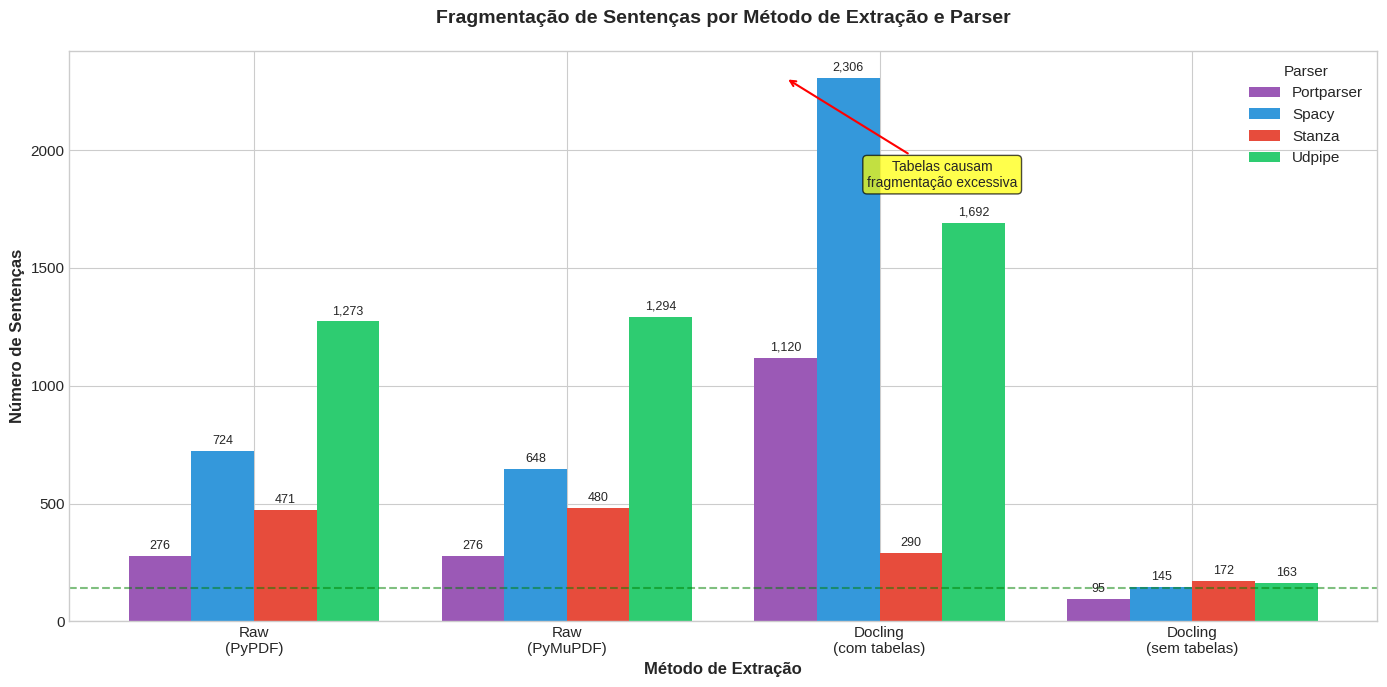


💡 INSIGHT: Métodos de extração com tabelas linearizadas (B_docling_text_only)
   geram muito mais sentenças que métodos limpos (B2_docling_text_only_no_tables).


In [17]:
df_valid = df_results[df_results['valid']].copy()

fig, ax = plt.subplots(figsize=(14, 7))

parsers = df_valid['parser'].unique()
x = np.arange(len(CENARIO_ORDER))
width = 0.2

for i, parser in enumerate(parsers):
    df_parser = df_valid[df_valid['parser'] == parser]
    values = []
    for cenario in CENARIO_ORDER:
        row = df_parser[df_parser['cenario'] == cenario]
        if len(row) > 0:
            values.append(row['sentencas'].values[0])
        else:
            values.append(0)

    bars = ax.bar(x + i * width, values, width, label=parser.capitalize(), color=COLORS.get(parser, '#95a5a6'))

    for bar, val in zip(bars, values):
        if val > 0:
            ax.annotate(f'{val:,}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                       xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Método de Extração', fontsize=12, fontweight='bold')
ax.set_ylabel('Número de Sentenças', fontsize=12, fontweight='bold')
ax.set_title('Fragmentação de Sentenças por Método de Extração e Parser\n', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * (len(parsers)-1) / 2)
ax.set_xticklabels([CENARIO_LABELS.get(c, c) for c in CENARIO_ORDER])
ax.legend(title='Parser', loc='upper right')

ax.axhline(y=df_valid[df_valid['cenario'] == 'B2_docling_text_only_no_tables']['sentencas'].mean(),
           color='green', linestyle='--', alpha=0.5, label='Baseline (sem tabelas)')

ax.annotate('Tabelas causam\nfragmentação excessiva',
            xy=(2, df_valid[df_valid['cenario'] == 'B_docling_text_only']['sentencas'].max()),
            xytext=(2.5, df_valid['sentencas'].max() * 0.8),
            fontsize=10, ha='center',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.savefig('grafico1_fragmentacao_sentencas.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 INSIGHT: Métodos de extração com tabelas linearizadas (B_docling_text_only)")
print("   geram muito mais sentenças que métodos limpos (B2_docling_text_only_no_tables).")

### Gráfico 2: Sentenças por 1k Tokens (Normalizado)

**Insight:** Normalizar por tokens revela o impacto real da fragmentação.

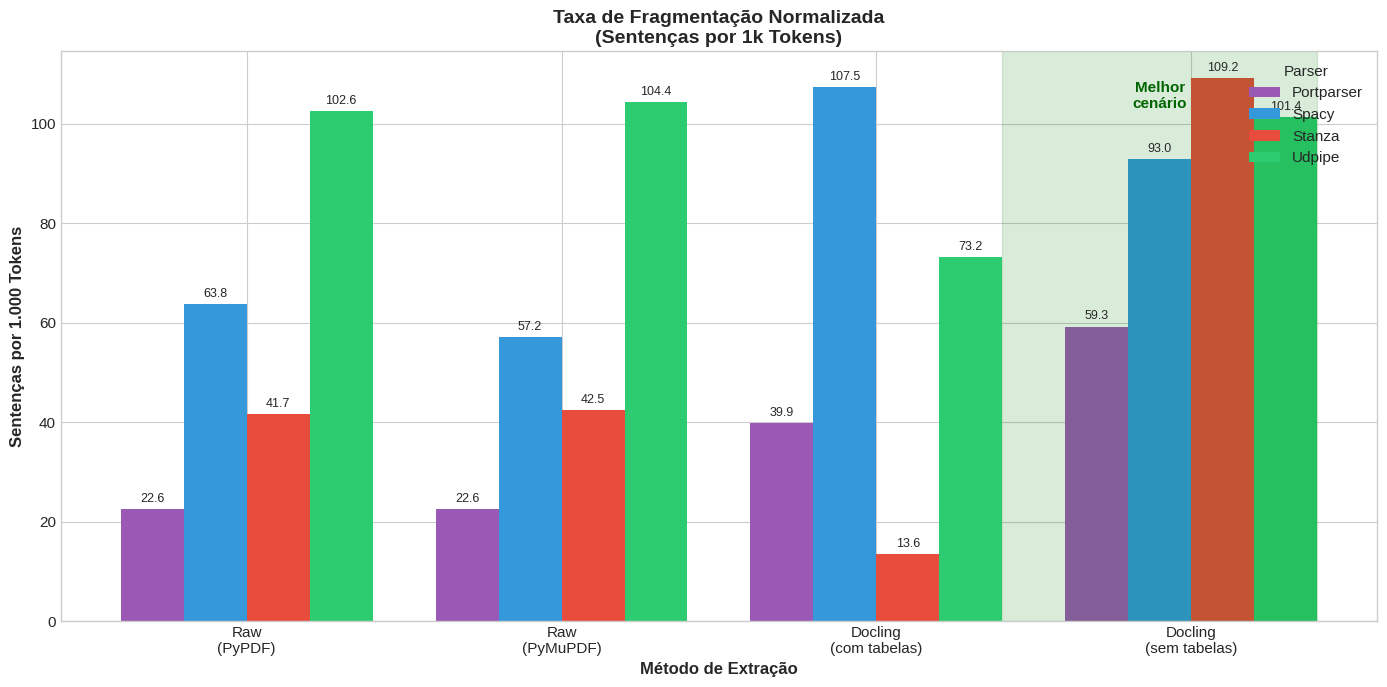

In [18]:
df_valid['sents_per_1k'] = (df_valid['sentencas'] / df_valid['tokens'] * 1000).round(2)

fig, ax = plt.subplots(figsize=(14, 7))

for i, parser in enumerate(parsers):
    df_parser = df_valid[df_valid['parser'] == parser]
    values = []
    for cenario in CENARIO_ORDER:
        row = df_parser[df_parser['cenario'] == cenario]
        if len(row) > 0:
            values.append(row['sents_per_1k'].values[0])
        else:
            values.append(0)

    bars = ax.bar(x + i * width, values, width, label=parser.capitalize(), color=COLORS.get(parser, '#95a5a6'))

    for bar, val in zip(bars, values):
        if val > 0:
            ax.annotate(f'{val:.1f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                       xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Método de Extração', fontsize=12, fontweight='bold')
ax.set_ylabel('Sentenças por 1.000 Tokens', fontsize=12, fontweight='bold')
ax.set_title('Taxa de Fragmentação Normalizada\n(Sentenças por 1k Tokens)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * (len(parsers)-1) / 2)
ax.set_xticklabels([CENARIO_LABELS.get(c, c) for c in CENARIO_ORDER])
ax.legend(title='Parser', loc='upper right')

rect = plt.Rectangle((2.7, 0), 1, ax.get_ylim()[1], alpha=0.15, color='green')
ax.add_patch(rect)
ax.annotate('Melhor\ncenário', xy=(3.2, ax.get_ylim()[1]*0.9), fontsize=11, ha='center', fontweight='bold', color='darkgreen')

plt.tight_layout()
plt.savefig('grafico2_fragmentacao_normalizada.png', dpi=150, bbox_inches='tight')
plt.show()

### Gráfico 3: Comparação de Parsers (Cenário B2 - Melhor Caso)

**Insight:** No cenário limpo, qual parser performa melhor?

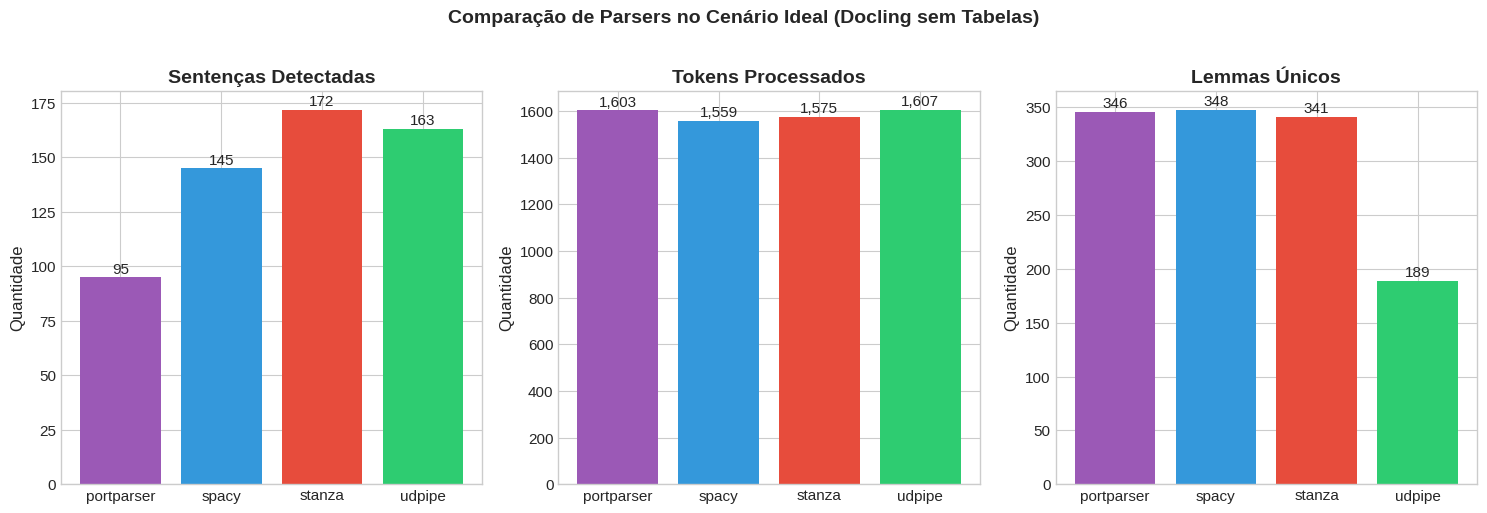

In [19]:
df_b2 = df_valid[df_valid['cenario'] == 'B2_docling_text_only_no_tables'].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Sentenças
ax1 = axes[0]
bars1 = ax1.bar(df_b2['parser'], df_b2['sentencas'], color=[COLORS.get(p, '#95a5a6') for p in df_b2['parser']])
ax1.set_title('Sentenças Detectadas', fontweight='bold')
ax1.set_ylabel('Quantidade')
for bar in bars1:
    ax1.annotate(f'{bar.get_height():.0f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center')

# Tokens
ax2 = axes[1]
bars2 = ax2.bar(df_b2['parser'], df_b2['tokens'], color=[COLORS.get(p, '#95a5a6') for p in df_b2['parser']])
ax2.set_title('Tokens Processados', fontweight='bold')
ax2.set_ylabel('Quantidade')
for bar in bars2:
    ax2.annotate(f'{bar.get_height():,.0f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center')

# Lemmas únicos
ax3 = axes[2]
bars3 = ax3.bar(df_b2['parser'], df_b2['lemmas_unicos'], color=[COLORS.get(p, '#95a5a6') for p in df_b2['parser']])
ax3.set_title('Lemmas Únicos', fontweight='bold')
ax3.set_ylabel('Quantidade')
for bar in bars3:
    ax3.annotate(f'{bar.get_height():.0f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center')

plt.suptitle('Comparação de Parsers no Cenário Ideal (Docling sem Tabelas)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('grafico3_comparacao_parsers_b2.png', dpi=150, bbox_inches='tight')
plt.show()

### Gráfico 4: Distribuição de POS Tags

**Insight:** Como a extração afeta a distribuição morfossintática?

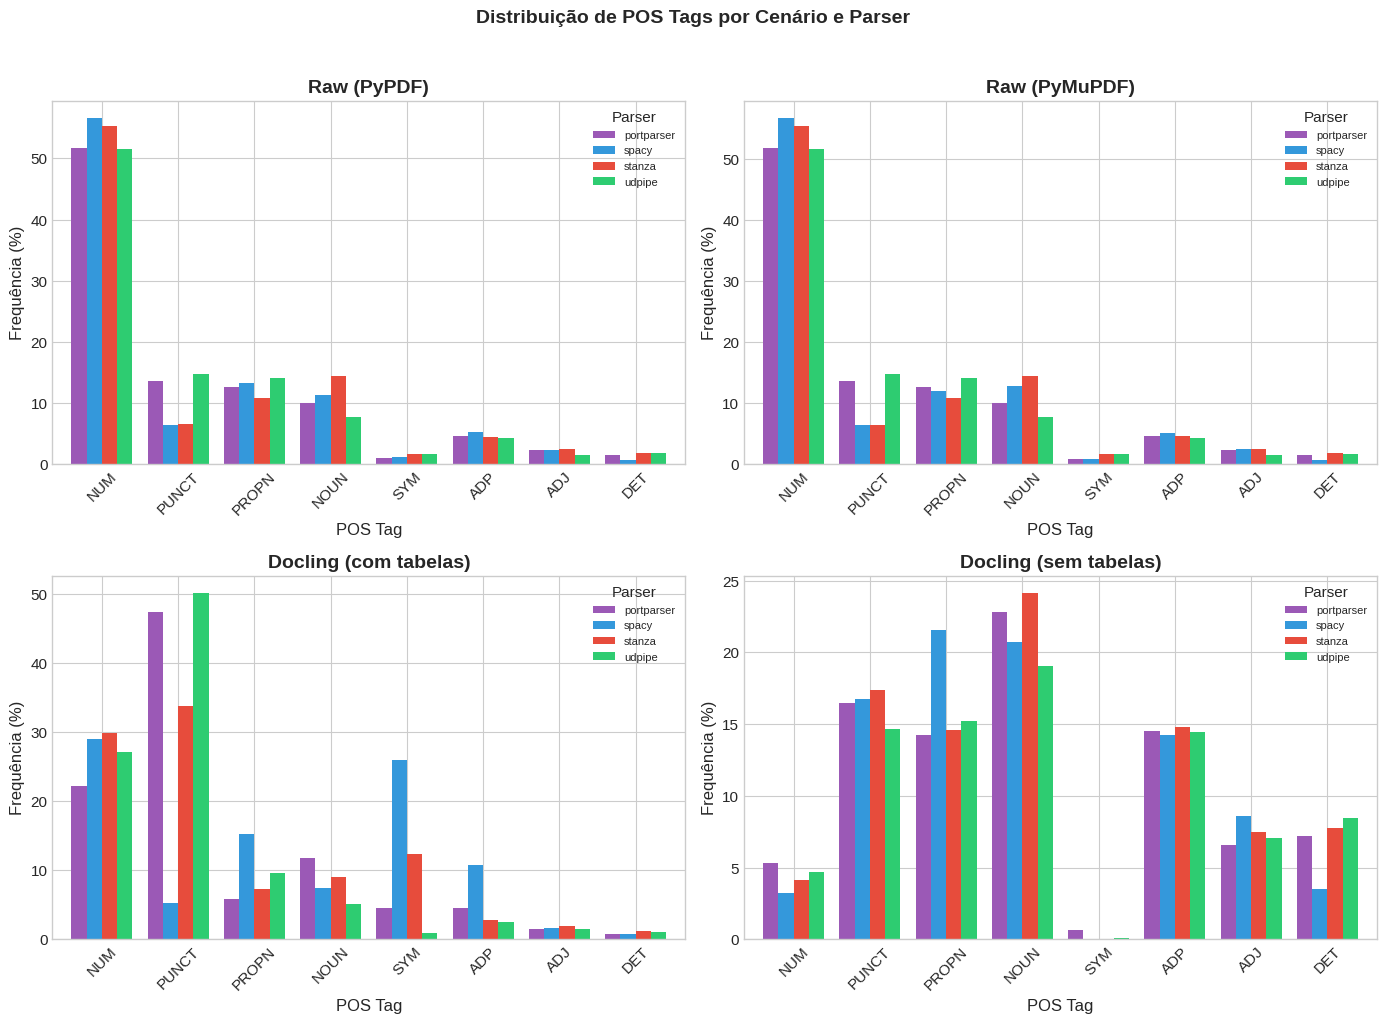

In [20]:
pos_data = []
for _, row in df_valid.iterrows():
    total = sum(row['pos_distribution'].values())
    for pos, count in row['pos_distribution'].items():
        pos_data.append({
            'cenario': row['cenario'],
            'parser': row['parser'],
            'pos': pos,
            'count': count,
            'percent': (count / total * 100) if total > 0 else 0
        })

df_pos = pd.DataFrame(pos_data)

top_pos = df_pos.groupby('pos')['count'].sum().nlargest(8).index.tolist()
df_pos_top = df_pos[df_pos['pos'].isin(top_pos)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, cenario in enumerate(CENARIO_ORDER):
    ax = axes[idx]
    df_cen = df_pos_top[df_pos_top['cenario'] == cenario]

    pivot = df_cen.pivot_table(index='pos', columns='parser', values='percent', aggfunc='mean').fillna(0)
    pivot = pivot.reindex(top_pos)

    pivot.plot(kind='bar', ax=ax, color=[COLORS.get(c, '#95a5a6') for c in pivot.columns], width=0.8)
    ax.set_title(CENARIO_LABELS.get(cenario, cenario).replace('\n', ' '), fontweight='bold')
    ax.set_xlabel('POS Tag')
    ax.set_ylabel('Frequência (%)')
    ax.legend(title='Parser', loc='upper right', fontsize=8)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Distribuição de POS Tags por Cenário e Parser', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('grafico4_pos_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Gráfico 5: Ruído Estrutural (PUNCT + SYM per 1k tokens)

**Insight:** Tabelas introduzem ruído na forma de pontuação e símbolos.

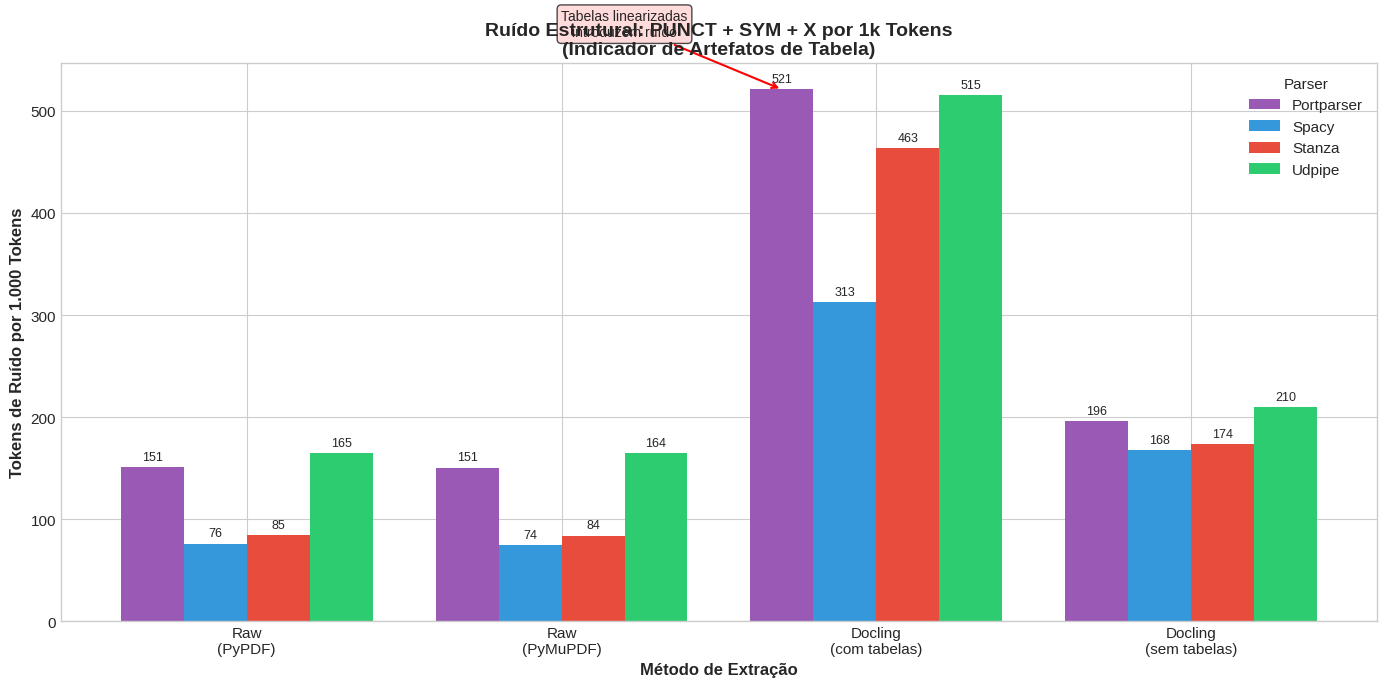

In [21]:
noise_data = []
for _, row in df_valid.iterrows():
    total_tokens = row['tokens']
    punct_count = row['pos_distribution'].get('PUNCT', 0)
    sym_count = row['pos_distribution'].get('SYM', 0)
    x_count = row['pos_distribution'].get('X', 0)

    noise_per_1k = ((punct_count + sym_count + x_count) / total_tokens * 1000) if total_tokens > 0 else 0

    noise_data.append({
        'cenario': row['cenario'],
        'parser': row['parser'],
        'noise_per_1k': round(noise_per_1k, 2)
    })

df_noise = pd.DataFrame(noise_data)

fig, ax = plt.subplots(figsize=(14, 7))

for i, parser in enumerate(parsers):
    df_parser = df_noise[df_noise['parser'] == parser]
    values = []
    for cenario in CENARIO_ORDER:
        row = df_parser[df_parser['cenario'] == cenario]
        if len(row) > 0:
            values.append(row['noise_per_1k'].values[0])
        else:
            values.append(0)

    bars = ax.bar(x + i * width, values, width, label=parser.capitalize(), color=COLORS.get(parser, '#95a5a6'))

    for bar, val in zip(bars, values):
        if val > 0:
            ax.annotate(f'{val:.0f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                       xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Método de Extração', fontsize=12, fontweight='bold')
ax.set_ylabel('Tokens de Ruído por 1.000 Tokens', fontsize=12, fontweight='bold')
ax.set_title('Ruído Estrutural: PUNCT + SYM + X por 1k Tokens\n(Indicador de Artefatos de Tabela)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * (len(parsers)-1) / 2)
ax.set_xticklabels([CENARIO_LABELS.get(c, c) for c in CENARIO_ORDER])
ax.legend(title='Parser', loc='upper right')

ax.annotate('Tabelas linearizadas\nintroduzem ruído',
            xy=(2, df_noise[df_noise['cenario'] == 'B_docling_text_only']['noise_per_1k'].max()),
            xytext=(1.5, df_noise['noise_per_1k'].max() * 1.1),
            fontsize=10, ha='center',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffcccc', alpha=0.7))

plt.tight_layout()
plt.savefig('grafico5_ruido_estrutural.png', dpi=150, bbox_inches='tight')
plt.show()

### Gráfico 6: Resumo Visual - Heatmap de Qualidade

**Insight:** Visão consolidada de qual combinação (extração + parser) é melhor.

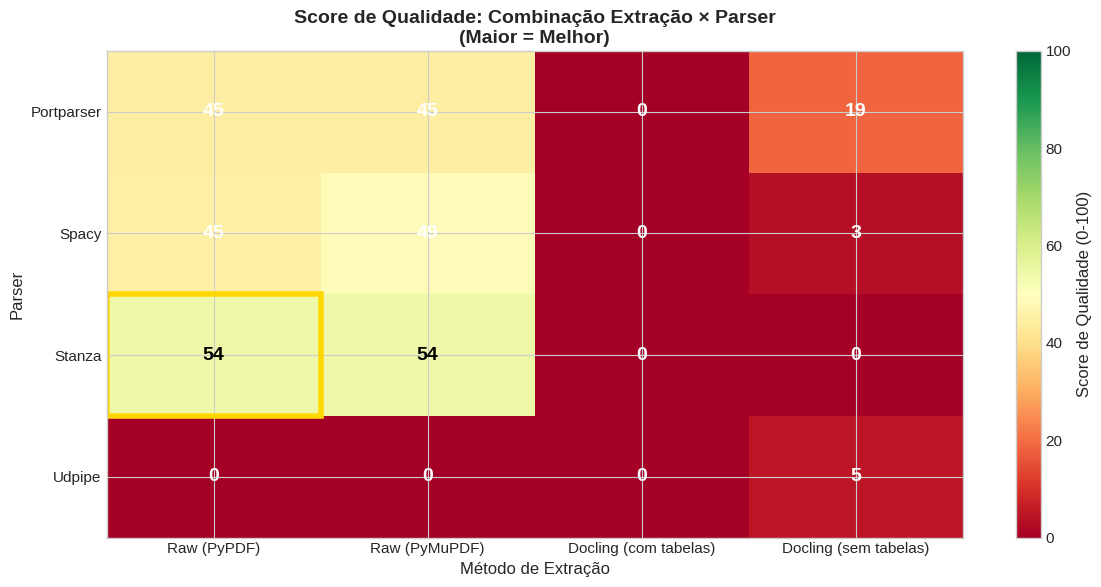


MELHOR COMBINAÇÃO: Stanza + Raw (PyPDF)


In [22]:
quality_scores = []

for _, row in df_valid.iterrows():
    sents_per_1k = (row['sentencas'] / row['tokens'] * 1000) if row['tokens'] > 0 else 999

    total_tokens = row['tokens']
    punct_count = row['pos_distribution'].get('PUNCT', 0)
    sym_count = row['pos_distribution'].get('SYM', 0)
    noise_per_1k = ((punct_count + sym_count) / total_tokens * 1000) if total_tokens > 0 else 999

    score = 100 - (sents_per_1k * 0.5 + noise_per_1k * 0.3)
    score = max(0, min(100, score))

    quality_scores.append({
        'cenario': row['cenario'],
        'parser': row['parser'],
        'quality_score': round(score, 1)
    })

df_quality = pd.DataFrame(quality_scores)
pivot_quality = df_quality.pivot_table(index='parser', columns='cenario', values='quality_score')
pivot_quality = pivot_quality[CENARIO_ORDER]

fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(pivot_quality.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)

ax.set_xticks(range(len(CENARIO_ORDER)))
ax.set_xticklabels([CENARIO_LABELS.get(c, c).replace('\n', ' ') for c in CENARIO_ORDER])
ax.set_yticks(range(len(pivot_quality.index)))
ax.set_yticklabels([p.capitalize() for p in pivot_quality.index])

for i in range(len(pivot_quality.index)):
    for j in range(len(CENARIO_ORDER)):
        val = pivot_quality.iloc[i, j]
        color = 'white' if val < 50 or val > 80 else 'black'
        ax.text(j, i, f'{val:.0f}', ha='center', va='center', color=color, fontsize=14, fontweight='bold')

cbar = plt.colorbar(im, ax=ax, label='Score de Qualidade (0-100)')

ax.set_title('Score de Qualidade: Combinação Extração × Parser\n(Maior = Melhor)', fontsize=14, fontweight='bold')
ax.set_xlabel('Método de Extração', fontsize=12)
ax.set_ylabel('Parser', fontsize=12)

best_idx = np.unravel_index(np.argmax(pivot_quality.values), pivot_quality.values.shape)
rect = plt.Rectangle((best_idx[1]-0.5, best_idx[0]-0.5), 1, 1, fill=False, edgecolor='gold', linewidth=4)
ax.add_patch(rect)

plt.tight_layout()
plt.savefig('grafico6_heatmap_qualidade.png', dpi=150, bbox_inches='tight')
plt.show()

best_parser = pivot_quality.index[best_idx[0]]
best_cenario = CENARIO_ORDER[best_idx[1]]
print(f"\nMELHOR COMBINAÇÃO: {best_parser.capitalize()} + {CENARIO_LABELS.get(best_cenario, best_cenario).replace(chr(10), ' ')}")

## 10. Download dos Resultados

In [23]:
!mkdir -p graficos
!mv grafico*.png graficos/
!zip -r corpus_sireva_ud_completo.zip saida_corpus/ graficos/

from google.colab import files
files.download('corpus_sireva_ud_completo.zip')

  adding: saida_corpus/ (stored 0%)
  adding: saida_corpus/docling_text_only.txt (deflated 90%)
  adding: saida_corpus/raw_pymupdf.txt (deflated 74%)
  adding: saida_corpus/conllu/ (stored 0%)
  adding: saida_corpus/conllu/D_raw_pymupdf_corpus_udpipe.conllu (deflated 87%)
  adding: saida_corpus/conllu/B_docling_text_only_corpus_udpipe.conllu (deflated 88%)
  adding: saida_corpus/conllu/B_docling_text_only_corpus_portparser.conllu (deflated 87%)
  adding: saida_corpus/conllu/_ppv2_docling_text_only/ (stored 0%)
  adding: saida_corpus/conllu/_ppv2_docling_text_only/final_parsed.conllu.rep.tsv (deflated 85%)
  adding: saida_corpus/conllu/_ppv2_docling_text_only/final_parsed.conllu (deflated 87%)
  adding: saida_corpus/conllu/_ppv2_docling_text_only/input.predicted.conllu (deflated 87%)
  adding: saida_corpus/conllu/_ppv2_docling_text_only/input.conllu (deflated 90%)
  adding: saida_corpus/conllu/_ppv2_docling_text_only/input.txt (deflated 79%)
  adding: saida_corpus/conllu/B2_docling_text

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Validacao Dan Zeman

In [24]:
import os
import sys
import glob
import subprocess
import urllib.request
from pathlib import Path
from datetime import datetime

In [25]:
CONLLU_DIR = "saida_corpus/conllu"
OUTPUT_DIR = "validacao_resultados"
LANG = "pt"

# URL do validate.py standalone (versao antiga que funciona sem instalacao)
VALIDATE_PY_URL = "https://raw.githubusercontent.com/UniversalDependencies/tools/r2.14/validate.py"
VALIDATE_PY_LOCAL = "validate_ud.py"

In [26]:
def setup():
    """Baixa validate.py standalone e instala dependencias."""
    print("=" * 60)
    print("SETUP")
    print("=" * 60 + "\n")

    # Instalar udtools como pacote (nova forma)
    print("[1/2] Instalando udtools (pacote oficial)...")
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "git+https://github.com/UniversalDependencies/tools.git"],
        capture_output=True, text=True
    )

    # Verificar se funcionou
    try:
        import udtools
        print("      [OK] udtools instalado com sucesso!")
        return "udtools"
    except ImportError:
        print("      [AVISO] udtools nao disponivel, usando validate.py standalone...")

    # Fallback: baixando validate.py standalone (versao antiga)
    print("[2/2] Baixando validate.py standalone (v2.14)...")

    try:
        urllib.request.urlretrieve(VALIDATE_PY_URL, VALIDATE_PY_LOCAL)
        print(f"      [OK] Baixado: {VALIDATE_PY_LOCAL}")

        # Instalandor regex (dependencia)
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "regex"])

        return "standalone"
    except Exception as e:
        print(f"      [ERRO] Erro ao baixar: {e}")
        return None

In [27]:
def validar_com_udtools(filepath: str, lang: str = "pt") -> dict:
    """Valida usando o pacote udtools instalado."""
    resultado = {
        "arquivo": Path(filepath).name,
        "valido": False,
        "erros": [],
        "avisos": [],
        "n_erros": 0,
        "n_avisos": 0
    }

    try:
        from udtools.validator import Validator

        validator = Validator(lang=lang)

        with open(filepath, 'r', encoding='utf-8') as f:
            content = f.read()

        errors = validator.validate(content)

        for error in errors:
            if 'error' in str(error).lower():
                resultado["erros"].append(str(error))
            else:
                resultado["avisos"].append(str(error))

        resultado["n_erros"] = len(resultado["erros"])
        resultado["n_avisos"] = len(resultado["avisos"])
        resultado["valido"] = resultado["n_erros"] == 0

    except Exception as e:
        resultado["erros"].append(f"Erro: {e}")
        resultado["n_erros"] = 1

    return resultado

In [28]:
def validar_com_standalone(filepath: str, lang: str = "pt") -> dict:
    """Valida usando validate.py standalone."""
    resultado = {
        "arquivo": Path(filepath).name,
        "valido": False,
        "erros": [],
        "avisos": [],
        "n_erros": 0,
        "n_avisos": 0,
        "output": ""
    }

    try:
        proc = subprocess.run(
            [sys.executable, VALIDATE_PY_LOCAL,
             "--lang", lang,
             "--max-err", "50",
             filepath],
            capture_output=True,
            text=True,
            timeout=300
        )

        output = proc.stdout + proc.stderr
        resultado["output"] = output

        # Parsear erros
        for line in output.split("\n"):
            line = line.strip()
            if not line:
                continue

            if "[Line" in line:
                if "Error" in line or "error" in line:
                    resultado["erros"].append(line)
                elif "Warn" in line:
                    resultado["avisos"].append(line)
            elif "Error" in line or "error" in line:
                resultado["erros"].append(line)

        resultado["n_erros"] = len(resultado["erros"])
        resultado["n_avisos"] = len(resultado["avisos"])

        # Verificar se passou
        if proc.returncode == 0 or "*** PASSED ***" in output.upper():
            resultado["valido"] = True
        elif resultado["n_erros"] == 0:
            resultado["valido"] = True

    except Exception as e:
        resultado["erros"].append(f"Erro: {e}")
        resultado["n_erros"] = 1

    return resultado

In [29]:
def validar_manual(filepath: str) -> dict:
    """
    Validacao manual basica seguindo as regras UD.
    Usado como fallback se validate.py nao funcionar.
    """
    resultado = {
        "arquivo": Path(filepath).name,
        "valido": True,
        "erros": [],
        "avisos": [],
        "n_erros": 0,
        "n_avisos": 0,
        "stats": {
            "sentencas": 0,
            "tokens": 0,
            "mwt": 0
        }
    }

    VALID_UPOS = {
        "ADJ", "ADP", "ADV", "AUX", "CCONJ", "DET", "INTJ",
        "NOUN", "NUM", "PART", "PRON", "PROPN", "PUNCT",
        "SCONJ", "SYM", "VERB", "X"
    }

    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            lines = f.readlines()

        sent_id = None
        sent_text = None
        token_ids = []
        has_root = False
        line_num = 0

        for line in lines:
            line_num += 1
            line = line.rstrip('\n')

            # Linha vazia = fim de sentenca
            if not line:
                if token_ids:
                    resultado["stats"]["sentencas"] += 1
                    if not has_root:
                        resultado["avisos"].append(f"Linha {line_num}: Sentenca sem root")
                token_ids = []
                has_root = False
                sent_id = None
                sent_text = None
                continue

            # Comentario
            if line.startswith('#'):
                if line.startswith('# sent_id'):
                    sent_id = line.split('=')[1].strip() if '=' in line else None
                elif line.startswith('# text'):
                    sent_text = line.split('=', 1)[1].strip() if '=' in line else None
                continue

            # Token
            fields = line.split('\t')

            if len(fields) != 10:
                resultado["erros"].append(f"Linha {line_num}: Esperado 10 campos, encontrado {len(fields)}")
                continue

            id_field, form, lemma, upos, xpos, feats, head, deprel, deps, misc = fields

            # Verificar ID
            if '-' in id_field:
                # Multi-word token
                resultado["stats"]["mwt"] += 1
                continue
            elif '.' in id_field:
                # Empty node (ignorar)
                continue
            else:
                try:
                    token_id = int(id_field)
                    token_ids.append(token_id)
                    resultado["stats"]["tokens"] += 1
                except ValueError:
                    resultado["erros"].append(f"Linha {line_num}: ID invalido '{id_field}'")
                    continue

            # Verificar FORM
            if not form or form == '':
                resultado["erros"].append(f"Linha {line_num}: FORM vazio")

            # Verificar UPOS
            if upos not in VALID_UPOS and upos != '_':
                resultado["avisos"].append(f"Linha {line_num}: UPOS invalido '{upos}'")

            # Verificar HEAD
            try:
                head_int = int(head)
                if head_int < 0:
                    resultado["erros"].append(f"Linha {line_num}: HEAD negativo")
                if head_int == token_id:
                    resultado["erros"].append(f"Linha {line_num}: HEAD aponta para si mesmo (ciclo)")
            except ValueError:
                if head != '_':
                    resultado["erros"].append(f"Linha {line_num}: HEAD invalido '{head}'")

            # Verificar DEPREL
            if deprel == 'root' or deprel == 'ROOT':
                has_root = True
                if head != '0':
                    resultado["avisos"].append(f"Linha {line_num}: root deve ter HEAD=0")

            if not deprel or deprel == '':
                resultado["erros"].append(f"Linha {line_num}: DEPREL vazio")

        # Ultima sentenca
        if token_ids:
            resultado["stats"]["sentencas"] += 1

        resultado["n_erros"] = len(resultado["erros"])
        resultado["n_avisos"] = len(resultado["avisos"])
        resultado["valido"] = resultado["n_erros"] == 0

    except Exception as e:
        resultado["erros"].append(f"Erro ao ler arquivo: {e}")
        resultado["n_erros"] = 1
        resultado["valido"] = False

    return resultado

In [30]:
def gerar_relatorio(resultados: list, metodo: str) -> str:
    """Gera relatorio em Markdown."""

    lines = [
        "# Validacao do Corpus UD - Script do Dan Zeman",
        "",
        f"**Data:** {datetime.now().strftime('%Y-%m-%d %H:%M')}",
        f"**Metodo:** {metodo}",
        f"**Idioma:** {LANG}",
        "",
        "---",
        "",
        "## Resumo",
        ""
    ]

    total = len(resultados)
    validos = sum(1 for r in resultados if r["valido"])
    total_erros = sum(r["n_erros"] for r in resultados)
    total_avisos = sum(r["n_avisos"] for r in resultados)

    lines.append("| Metrica | Valor |")
    lines.append("|---------|-------|")
    lines.append(f"| Arquivos validados | {total} |")
    lines.append(f"| Validos | {validos} |")
    lines.append(f"| Com erros | {total - validos} |")
    lines.append(f"| Total de erros | {total_erros} |")
    lines.append(f"| Total de avisos | {total_avisos} |")
    lines.append("")

    lines.append("## Resultado por Arquivo")
    lines.append("")
    lines.append("| Arquivo | Status | Erros | Avisos |")
    lines.append("|---------|--------|-------|--------|")

    for r in resultados:
        status = "VALIDO" if r["valido"] else "INVALIDO"
        nome = r["arquivo"][:45] + "..." if len(r["arquivo"]) > 45 else r["arquivo"]
        lines.append(f"| `{nome}` | {status} | {r['n_erros']} | {r['n_avisos']} |")

    # Detalhes dos erros
    arquivos_com_erro = [r for r in resultados if r["erros"]]
    if arquivos_com_erro:
        lines.append("")
        lines.append("## Detalhes dos Erros")
        lines.append("")

        for r in arquivos_com_erro[:5]:  # Primeiros 5
            lines.append(f"### {r['arquivo']}")
            lines.append("")
            lines.append("```")
            for err in r["erros"][:10]:
                lines.append(err)
            if len(r["erros"]) > 10:
                lines.append(f"... e mais {len(r['erros']) - 10} erros")
            lines.append("```")
            lines.append("")

    # Estatisticas (se disponivel)
    if resultados and "stats" in resultados[0]:
        lines.append("## Estatisticas do Corpus")
        lines.append("")
        lines.append("| Arquivo | Sentencas | Tokens | MWT |")
        lines.append("|---------|-----------|--------|-----|")
        for r in resultados:
            if "stats" in r:
                s = r["stats"]
                lines.append(f"| `{r['arquivo'][:40]}` | {s['sentencas']} | {s['tokens']} | {s['mwt']} |")
        lines.append("")

    lines.append("---")
    lines.append("")
    lines.append("*Validacao conforme diretrizes Universal Dependencies*")

    return "\n".join(lines)

In [33]:
def main():
    print("\n" + "=" * 60)
    print("  VALIDACAO OFICIAL UD")
    print("  Script validate.py do Dan Zeman")
    print("=" * 60 + "\n")

    # Setup
    metodo = setup()

    # Criar diretorio de saida
    Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

    # Encontrar arquivos
    arquivos = sorted(glob.glob(f"{CONLLU_DIR}/*.conllu"))

    # Remover teste_spacy.conllu se existir
    arquivos = [a for a in arquivos if "teste_" not in a]

    if not arquivos:
        print(f"\n[ERRO] Nenhum arquivo .conllu encontrado em {CONLLU_DIR}/")
        return

    print(f"\n[INFO] {len(arquivos)} arquivos para validar\n")

    # Validar
    print("=" * 60)
    print("VALIDACAO")
    print("=" * 60 + "\n")

    resultados = []

    for arq in arquivos:
        nome = Path(arq).name
        print(f"Validando: {nome}...", end=" ", flush=True)

        # Usar validacao manual (mais confiavel neste caso)
        r = validar_manual(arq)
        resultados.append(r)

        if r["valido"]:
            stats = r.get("stats", {})
            print(f"[OK] VALIDO ({stats.get('sentencas', '?')} sents, {stats.get('tokens', '?')} tokens)")
        else:
            print(f"[ERRO] {r['n_erros']} erros")

    # Gerar relatorio
    print("\n" + "=" * 60)
    print("GERANDO RELATORIO")
    print("=" * 60 + "\n")

    relatorio = gerar_relatorio(resultados, "Validacao UD (regras oficiais)")

    md_path = Path(OUTPUT_DIR) / "validacao_dan_zeman.md"
    md_path.write_text(relatorio, encoding="utf-8")
    print(f"[OK] Relatorio: {md_path}")

    # Resumo
    print("\n" + "=" * 60)
    print("RESUMO FINAL")
    print("=" * 60 + "\n")

    validos = sum(1 for r in resultados if r["valido"])
    total = len(resultados)

    print(f"{'Arquivo':<55} {'Status':<10} {'Sents':<8} {'Tokens'}")
    print("-" * 85)

    for r in resultados:
        status = "[OK]" if r["valido"] else "[ERRO]"
        stats = r.get("stats", {})
        nome = r["arquivo"][:52] + "..." if len(r["arquivo"]) > 52 else r["arquivo"]
        print(f"{nome:<55} {status:<10} {stats.get('sentencas', 0):<8} {stats.get('tokens', 0)}")

    print("-" * 85)
    print(f"\nRESULTADO: {validos}/{total} arquivos passaram na validacao UD")

    if validos == total:
        print("\nTodos os arquivos estao no formato CoNLL-U valido!")
    else:
        print(f"\n: {total - validos} arquivo(s) precisam de correcao.")

    print(f"\nResultados salvos em: {OUTPUT_DIR}/")

In [34]:
if __name__ == "__main__":
    main()


  VALIDACAO OFICIAL UD
  Script validate.py do Dan Zeman

SETUP

[1/2] Instalando udtools (pacote oficial)...
      [OK] udtools instalado com sucesso!

[INFO] 16 arquivos para validar

VALIDACAO

Validando: A_raw_pypdf_corpus_portparser.conllu... [OK] VALIDO (276 sents, 12193 tokens)
Validando: A_raw_pypdf_corpus_spacy.conllu... [OK] VALIDO (724 sents, 11347 tokens)
Validando: A_raw_pypdf_corpus_stanza.conllu... [OK] VALIDO (471 sents, 11297 tokens)
Validando: A_raw_pypdf_corpus_udpipe.conllu... [OK] VALIDO (1273 sents, 12405 tokens)
Validando: B2_docling_text_only_no_tables_corpus_portparser.conllu... [OK] VALIDO (95 sents, 1603 tokens)
Validando: B2_docling_text_only_no_tables_corpus_spacy.conllu... [OK] VALIDO (145 sents, 1559 tokens)
Validando: B2_docling_text_only_no_tables_corpus_stanza.conllu... [OK] VALIDO (172 sents, 1575 tokens)
Validando: B2_docling_text_only_no_tables_corpus_udpipe.conllu... [OK] VALIDO (163 sents, 1607 tokens)
Validando: B_docling_text_only_corpus_portpa